# **Predicción de Churn de Clientes: Pipeline End-to-End con Despliegue en Producción**

## **Customer Churn Prediction: From Data to Deployed API**

**Autora:** Almy Ventura

**Fecha:** Julio 2026

**Stack:** Python · Pandas · Scikit-learn · FastAPI · Docker · Streamlit

## **Introducción**

La retención de clientes es uno de los desafíos más costosos y recurrentes en industrias como telecomunicaciones, banca y servicios financieros: adquirir un cliente nuevo suele costar significativamente más que retener uno existente. Este proyecto aborda el problema de **churn prediction** (predicción de fuga de clientes), utilizando el dataset público *Telco Customer Churn*, que contiene información demográfica, de contrato y de consumo de una empresa de telecomunicaciones.

Más allá del modelado, este proyecto busca demostrar el ciclo completo de un producto de datos: desde la limpieza y exploración de los datos, pasando por el entrenamiento y evaluación de un modelo de clasificación, hasta su despliegue como un servicio accesible vía API, containerizado con Docker y expuesto a través de un dashboard interactivo.

## **Metodología**

El desarrollo sigue un enfoque estructurado en las siguientes etapas:

1. **ETL (Extract, Transform, Load):** limpieza de datos, tratamiento de valores nulos/inconsistentes, y transformación de variables categóricas.
2. **Análisis Exploratorio de Datos (EDA):** identificación de patrones, correlaciones y variables con mayor poder predictivo respecto al churn.
3. **Entrenamiento y evaluación del modelo:** comparación de algoritmos de clasificación (ej. Regresión Logística, Random Forest), utilizando métricas apropiadas para clasificación binaria con clases desbalanceadas (precisión, recall, F1-score, AUC-ROC).
4. **Mejora iterativa del modelo:** ajuste de hiperparámetros y feature engineering basado en los resultados de evaluación.
5. **Serialización del modelo:** exportación del modelo final entrenado para su uso en producción.
6. **Desarrollo de una API REST:** exposición del modelo mediante FastAPI, permitiendo predicciones en tiempo real.
7. **Containerización:** empaquetado de la API con Docker para garantizar reproducibilidad del entorno.
8. **Despliegue:** publicación del servicio en una plataforma cloud (Render/Railway).
9. **Dashboard interactivo:** interfaz simple en Streamlit para consumir la API sin necesidad de conocimientos técnicos.

## **Objetivo**

Desarrollar un modelo de clasificación capaz de predecir la probabilidad de que un cliente abandone el servicio (*churn*), e implementarlo como un sistema productivo completo, no solo como un modelo experimental, demostrando competencias en el ciclo de vida completo de un proyecto de Machine Learning: desde el análisis de datos hasta el despliegue en un entorno accesible.

## **Diccionario de variables**

**Información demográfica**

| Variable | Tipo | Descripción | Valores posibles |
|---|---|---|---|
| `gender` | Categórica | Género del cliente | Male, Female |
| `SeniorCitizen` | Binaria (0/1) | Si el cliente es adulto mayor | 0 = No, 1 = Sí |
| `Partner` | Categórica | Si el cliente tiene pareja | Yes, No |
| `Dependents` | Categórica | Si el cliente tiene dependientes | Yes, No |


**Servicios contratados**

| Variable | Tipo | Descripción | Valores posibles |
|---|---|---|---|
| `PhoneService` | Categórica | Si tiene servicio telefónico | Yes, No |
| `MultipleLines` | Categórica | Si tiene múltiples líneas | Yes, No, No phone service |
| `InternetService` | Categórica | Tipo de servicio de internet | DSL, Fiber optic, No |
| `OnlineSecurity` | Categórica | Si tiene seguridad en línea | Yes, No, No internet service |
| `OnlineBackup` | Categórica | Si tiene respaldo en línea | Yes, No, No internet service |
| `DeviceProtection` | Categórica | Si tiene protección de dispositivo | Yes, No, No internet service |
| `TechSupport` | Categórica | Si tiene soporte técnico | Yes, No, No internet service |
| `StreamingTV` | Categórica | Si tiene streaming de TV | Yes, No, No internet service |
| `StreamingMovies` | Categórica | Si tiene streaming de películas | Yes, No, No internet service |


**Cuenta y contrato**

| Variable | Tipo | Descripción | Valores posibles |
|---|---|---|---|
| `tenure` | Numérica | Meses de antigüedad como cliente | 0 – 72 |
| `Contract` | Categórica | Tipo de contrato | Month-to-month, One year, Two year |
| `PaperlessBilling` | Categórica | Si usa facturación electrónica | Yes, No |
| `PaymentMethod` | Categórica | Método de pago | Electronic check, Mailed check, Bank transfer, Credit card |
| `MonthlyCharges` | Numérica | Cargo mensual | Valor continuo en USD |
| `TotalCharges` | Numérica | Cargo total acumulado | Valor continuo en USD |


**Variable objetivo**

| Variable | Tipo | Descripción | Valores posibles |
|---|---|---|---|
| `Churn` | Categórica (target) | Si el cliente abandonó el servicio | Yes, No |


---
## **Desarrollo del Experimento**

In [ ]:
# Montamos Google Drive para poder acceder a los archivos guardados ahí
# (el dataset, y luego el modelo entrenado) de forma persistente entre sesiones.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile  # Librería para trabajar con archivos comprimidos (.zip)
import os       # Librería para interactuar con el sistema de archivos (crear carpetas, listar archivos, etc.)

# Ruta donde está guardado el archivo .zip descargado de Kaggle
zip_path = '/content/drive/MyDrive/Colab Notebooks/datasets/archive.zip'

# Carpeta donde vamos a extraer el contenido del .zip
extract_path = '/content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/'

# Creamos la carpeta de destino si no existe todavía (evita error si ya existe)
os.makedirs(extract_path, exist_ok=True)

# Abrimos el .zip en modo lectura y extraemos todo su contenido a la carpeta destino
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Imprimimos los archivos extraídos para confirmar que todo salió bien
# y saber el nombre exacto del CSV para el siguiente paso
print("Archivos extraídos:", os.listdir(extract_path))

Archivos extraídos: ['telco_churn_clean.csv', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [ ]:
import pandas as pd  # Librería principal para manipulación de datos en tablas (DataFrames)

# Cargamos el CSV extraído en un DataFrame de pandas.
# Ajustar el nombre del archivo según lo que haya impreso la celda anterior.
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Mostramos las primeras 5 filas para verificar que se cargó correctamente
# y tener una primera idea de las columnas disponibles
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



## **1. ETL (Extract, Transform, Load)**
Limpieza de datos y preparación de variables para el análisis y modelado.

---
### **1.1 EXTRACT**

El dataset ya fue cargado en la celda anterior como 'df'.

In [ ]:
# Revisamos su estructura general: tipos de datos, nulos, dimensiones.
df.info()

# Revisamos si hay valores nulos explícitos en cada columna
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#### 1.1.1 Interpretación

Como se puede observar en la exploración inicial del DataFrame, no se detectaron valores nulos de forma explícita; sin embargo, algunas de las variables se encuentran almacenadas en formato *object*, lo cual no es adecuado para el análisis y la construcción del modelo. Cabe destacar que, al estar la mayoría de las variables en este formato, será necesario aplicar estrategias de *encoding* para optimizar el desempeño del modelo, dado que la librería utilizada no admite texto sin procesar como entrada.

---
### **1.2 TRANSFORM**

In [ ]:
# Columna 'customerID': es solo un identificador único, no aporta valor predictivo.
# La eliminamos porque no debe usarse como feature del modelo.
df = df.drop('customerID', axis=1)

# Columna 'TotalCharges': pandas la carga como texto (string) en vez de número,
# porque algunos clientes con tenure=0 (recién llegados) tienen un espacio en blanco
# en vez de un valor numérico. Hay que convertirla a número y manejar esos casos.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# 'coerce' convierte los valores no numéricos (los espacios en blanco) en NaN

# Verificamos cuántos valores quedaron como NaN tras la conversión
print("Valores nulos en TotalCharges tras conversión:", df['TotalCharges'].isnull().sum())

Valores nulos en TotalCharges tras conversión: 11


In [ ]:
# Esos NaN corresponden a clientes nuevos (tenure = 0), donde tiene sentido
# que el gasto total acumulado sea 0, ya que aún no han sido facturados.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirmamos que ya no quedan nulos
df['TotalCharges'].isnull().sum()

np.int64(0)

In [ ]:
# La variable objetivo 'Churn' viene como texto ('Yes'/'No').
# La convertimos a formato numérico (1/0), que es lo que espera scikit-learn.
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verificamos el balance de clases: cuántos clientes se fueron vs. se quedaron
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


#### **1.2.1 Justificación de decisiones tomadas:**

**Sobre la eliminación de `customerID`:**

Esta variable es un identificador único por cliente, sin ningún valor predictivo intrínseco, por lo que, no existe una relación lógica entre el identificador asignado a un cliente y su probabilidad de abandono. Incluirla en el modelo introduciría ruido y un riesgo real de sobreajuste (*overfitting*), ya que el modelo podría "memorizar" identificadores específicos en lugar de aprender patrones generalizables. Por esta razón, se eliminó de forma justificada.

**Sobre la conversión de `TotalCharges`:**

Tras forzar la conversión a formato numérico, se identificaron 11 valores nulos que no habían sido detectados en la exploración inicial, precisamente porque estaban almacenados como espacios en blanco en lugar de valores faltantes explícitos. Al analizar estos casos, se observó que corresponden a clientes con `tenure = 0`, es decir, clientes recién adquiridos que aún no han completado su primer ciclo de facturación. Dado este contexto de negocio, imputar estos valores con 0 no constituye una estimación estadística arbitraria, sino que refleja fielmente la realidad: un cliente que aún no ha sido facturado tiene, correctamente, un gasto total acumulado de cero. Dada la magnitud reducida de estos casos, esta decisión tiene un impacto sobre el conjunto de datos.

**Sobre el balance de clases en la variable objetivo:**

La distribución de `Churn` muestra que un 73.46% de los clientes no abandonaron el servicio, mientras que un 26.54% sí lo hizo. Esto representa un **desbalance moderado de clases**, no extremo, pero suficientemente relevante como para tenerlo en cuenta durante la fase de modelado. Un desbalance de esta magnitud implica que la métrica de *accuracy* (exactitud) por sí sola puede resultar engañosa, un modelo que prediga siempre "no churn" alcanzaría automáticamente un ~73% de exactitud sin haber aprendido ningún patrón útil. Por este motivo, será necesario priorizar métricas más informativas para este contexto, como *precision*, *recall*, *F1-score* y *AUC-ROC*, especialmente enfocadas en el desempeño del modelo sobre la clase minoritaria (clientes que sí abandonan), que es la que tiene mayor relevancia de negocio.

In [ ]:
# Antes de codificar, separamos las columnas categóricas en dos grupos,
# porque cada tipo requiere una estrategia de encoding distinta:
#   1. Binarias (solo 2 valores posibles, ej. "Yes"/"No")
#   2. Multi-categoría (3 o más valores posibles)

# Revisamos cuántos valores únicos tiene cada columna categórica
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


#### **1.2.2 Encoding de variables binarias**

In [ ]:
# Para variables con exactamente 2 categorías, usamos mapeo directo a 0/1.
# Esto es más eficiente que one-hot encoding cuando solo hay 2 opciones,
# ya que no genera columnas adicionales innecesarias.

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 'gender' es un caso especial de variable binaria, pero con etiquetas distintas
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

#### **1.2.3 Encoding de variables multi-categoría**

In [ ]:
# Estas columnas tienen 3 o más valores posibles (incluyendo variantes como
# "No internet service" o "No phone service", que técnicamente son una
# tercera categoría, no solo "Sí/No").
#
# Usamos One-Hot Encoding: convierte cada categoría en una columna binaria propia.
# Esto evita que el modelo asuma una relación de orden inexistente entre categorías
# (por ejemplo, que "Two year" > "One year" > "Month-to-month" numéricamente,
# cuando en realidad son categorías sin jerarquía matemática real).

multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# drop_first=True elimina una categoría de referencia por variable,
# para evitar multicolinealidad (redundancia matemática entre columnas)
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# Verificamos que ya no queden columnas de tipo texto
print("Columnas tipo object restantes:", df.select_dtypes(include='object').columns.tolist())

Columnas tipo object restantes: []


In [ ]:
# Revisión final: confirmamos la forma del dataset y que todas las columnas
# sean numéricas, listas para el modelado.
print("Dimensiones finales del dataset:", df.shape)
df.dtypes

Dimensiones finales del dataset: (7043, 31)


,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
PaperlessBilling,int64
MonthlyCharges,float64
TotalCharges,float64
Churn,int64


#### 1.2.4 Interpretación

Tras el proceso de *encoding*, el dataset pasó de 21 a 31 columnas, todas ellas en formato numérico o booleano, quedando así compatible con los algoritmos de *scikit-learn*. Este incremento en el número de columnas se debe a la estrategia utilizada para las variables multi-categoría: se aplicó *One-Hot Encoding*, que genera una columna binaria independiente por cada categoría (a excepción de una categoría de referencia, omitida mediante el parámetro `drop_first=True` para evitar multicolinealidad).

Se optó por esta técnica en lugar de una codificación numérica simple (*label encoding*) porque estas variables no poseen un orden jerárquico inherente, por ejemplo, no existe una relación de magnitud entre "DSL", "Fiber optic" y "No" en `InternetService`. Asignarles valores numéricos secuenciales (0, 1, 2) induciría al modelo a interpretar relaciones de orden inexistentes entre las categorías, distorsionando su aprendizaje. Para las variables estrictamente binarias (`gender`, `Partner`, `Dependents`, entre otras), en cambio, se utilizó un mapeo directo a 0/1, dado que en este caso no existe riesgo de introducir una jerarquía falsa al tratarse de solo dos posibles valores.

Con este paso, el dataset queda completamente numérico y listo para las siguientes etapas de análisis exploratorio y modelado.

### **1.3 LOAD**

Guardamos el dataset ya limpio y transformado como un nuevo archivo CSV. Esto genera un "checkpoint" reproducible: a partir de acá, el resto del pipeline (EDA, modelado) puede partir directamente de este archivo limpio, sin necesidad de volver a correr todo el proceso de ETL cada vez.

In [ ]:
output_path = '/content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/telco_churn_clean.csv'

df.to_csv(output_path, index=False)
# index=False evita que pandas agregue una columna extra con el índice numérico de fila

print(f"Dataset limpio guardado en: {output_path}")
print(f"Dimensiones finales: {df.shape}")

Dataset limpio guardado en: /content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/telco_churn_clean.csv
Dimensiones finales: (7043, 31)


### **1.4 Conclusión: ETL**

Con este proceso fundamental para el análisis de datos concluido, el conjunto de datos queda debidamente preparado para dar paso al Análisis Exploratorio de Datos correspondiente y su posterior partición (train/test). Esta siguiente etapa permitirá dar mayor sentido y contexto a la necesidad de identificar qué factores influyen con mayor relevancia en el abandono de los clientes, sentando así las bases para la construcción de un modelo predictivo fundamentado tanto en evidencia estadística como en comprensión del negocio.


## **2. Análisis Exploratorio de Datos (EDA)**
Exploración de patrones, distribuciones y relaciones entre variables y el churn.

### **2.1 Distribución de la variable objetivo (Churn)**

Antes de explorar cualquier variable predictora, es necesario entender el comportamiento de la variable objetivo por sí sola. Visualizar la distribución de Churn permite confirmar el nivel de balance entre clases, lo cual es un requisito previo indispensable para decidir correctamente qué métricas de evaluación usar más adelante y para poder interpretar con criterio cualquier resultado de asociación calculado en el resto del EDA.

In [ ]:
# Importación de librerias necesarias para la sección
import matplotlib.pyplot as plt  # Librería base para generar gráficos
import seaborn as sns            # Extensión de matplotlib con estilos y gráficos estadísticos listos
import numpy as np               # Operaciones numéricas (se usará más adelante en la sección)
import pandas as pd              # Manipulación de datos en DataFrames

In [ ]:
# Configuración para los gráfios
# Configuramos un estilo visual consistente para todos los gráficos del EDA,
# así no hay que repetir esta configuración en cada celda posterior.
sns.set_style('whitegrid')          # Fondo con cuadrícula suave, más fácil de leer
plt.rcParams['figure.figsize'] = (8, 5)  # Tamaño por defecto de las figuras

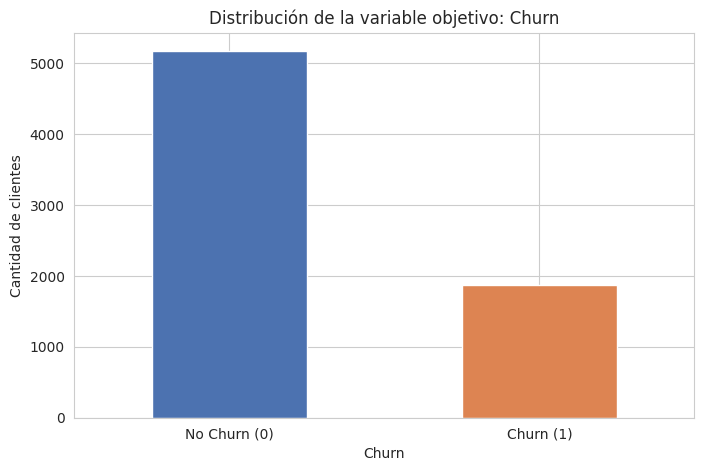

In [ ]:
# Contamos cuántos clientes hay en cada categoría de Churn (0 = no abandonó,
# 1 = sí abandonó) y lo graficamos como barras.
fig, ax = plt.subplots()

df['Churn'].value_counts().plot(
    kind='bar',                      # Tipo de gráfico: barras
    color=['#4C72B0', '#DD8452'],    # Un color distinto por clase, para diferenciarlas de un vistazo
    ax=ax
)

# Renombramos las etiquetas del eje X (por defecto saldrían "0" y "1",
# que no son autoexplicativas para alguien que lea el notebook sin contexto)
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
ax.set_ylabel('Cantidad de clientes')
ax.set_title('Distribución de la variable objetivo: Churn')

plt.show()

In [ ]:
# Además del gráfico, calculamos la proporción exacta de cada clase,
# ya que un gráfico de barras no siempre deja ver diferencias pequeñas
# con precisión numérica.
proporciones = df['Churn'].value_counts(normalize=True)
print("Proporción de clases:")
print(proporciones)

Proporción de clases:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


#### 2.1.1 Interpretación

El gráfico muestra que la clase No Churn (0) es claramente mayoritaria frente a Churn (1). Según las proporciones calculadas, cerca del 73% de los clientes no abandonó el servicio, mientras que el 27% restante sí lo hizo, resultado que confirma numéricamente lo que el gráfico representa visualmente. Esto evidencia un desbalance moderado entre clases, lo cual será relevante al elegir las métricas de evaluación en la sección de modelado.

### **2.2 Análisis de variables numéricas vs. Churn**

Esta sección analiza el comportamiento de las tres variables numéricas continuas del dataset (tenure, MonthlyCharges y TotalCharges), primero de forma individual para conocer su distribución general, y luego comparándolas según la clase de Churn, con el fin de identificar posibles diferencias que puedan servir como señales predictivas para el modelo.

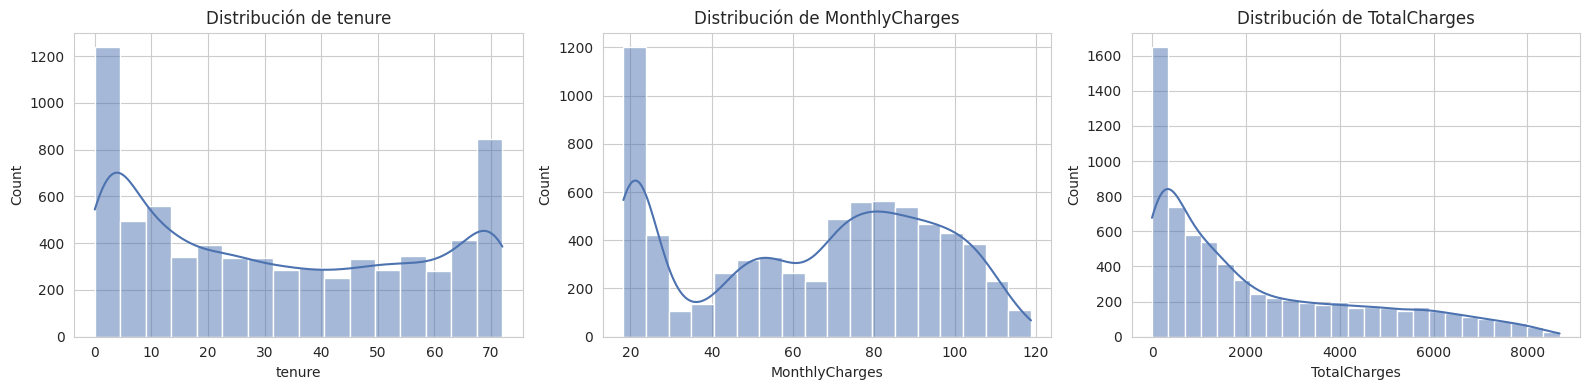

In [ ]:
 # Variables numéricas continuas a analizar
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Usamos histogramas con una curva de densidad (kde) superpuesta para ver
# tanto la forma general de la distribución como su tendencia suavizada.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col],
        kde=True,           # Agrega la curva de densidad estimada
        ax=axes[i],
        color='#4C72B0'
    )
    axes[i].set_title(f'Distribución de {col}')

plt.tight_layout()  # Ajusta el espaciado entre subgráficos para que no se solapen
plt.show()

#### 2.2.1 Interpretación de gráficos

Al observar el primer grafico, se puede identificar que la distribución de la variable *tenure* es bimodal, puesto a que la curva de densidad muestra 2 picos; uno cerca de los meses iniciales al servicio y otro cerca de los 70 meses de servicio, con una llamativa zona plana o llana en la sección intermedia. Con esto se puede evidenciar que la base de clientes está concentrada entre los clientes nuevos y los de larga permanencia, siendo los de antigüedad intermedia en comparación menos frecuentes a abandonar la compañía.

La distribución de *MonthlyCharges* también es bimodal, con un primer pico marcado cerca de los 20 USD y un segundo pico, más amplio, entre los 70 y 90 USD. Entre ambos picos, alrededor de los 35-40 USD, hay una caída notable en la cantidad de clientes. Esto sugiere dos grupos de cargo mensual bien diferenciados, uno de clientes con planes básicos de bajo costo, y otro de clientes con planes más completos o de mayor valor.

La distribución de *TotalCharges* presenta una distribución unimodal con fuerte sesgo a la derecha, la mayor concentración de clientes está en valores bajos (cerca de 0), y la frecuencia decrece de forma progresiva a medida que aumenta el monto acumulado, con una cola larga que se extiende hasta cerca de los 8000 USD. A diferencia de las otras dos variables, aquí no hay un segundo pico, solo una disminución continua.

### **2.3 Análisis de variables categóricas vs. Churn**

Esta sección analiza la relación entre las variables categóricas más relevantes (tipo de contrato, servicio de internet y método de pago) y la variable objetivo Churn, calculando la tasa de abandono específica para cada categoría.

In [ ]:
# Función para calcular la tasa de churn por cada categoría de una variable
# que fue codificada con pd.get_dummies(drop_first=True).
def tasa_churn_por_dummy(df, prefix, label_referencia):
    tasas = {}
    cols = [c for c in df.columns if c.startswith(prefix)]  # Columnas dummy de ese grupo

    for col in cols:
        nombre = col.replace(prefix, '')                         # Nombre limpio de la categoría (sin el prefijo)
        tasas[nombre] = df.loc[df[col] == True, 'Churn'].mean()  # Promedio de Churn donde esa dummy es True

# drop_first=True elimina una categoría (la de referencia); la reconstruimos
# identificando las filas donde TODAS las dummies del grupo son False
    ref_mask = (df[cols] == False).all(axis=1)
    tasas[label_referencia] = df.loc[ref_mask, 'Churn'].mean()

    return pd.Series(tasas).sort_values(ascending=False)  # Ordenado de mayor a menor tasa de churn

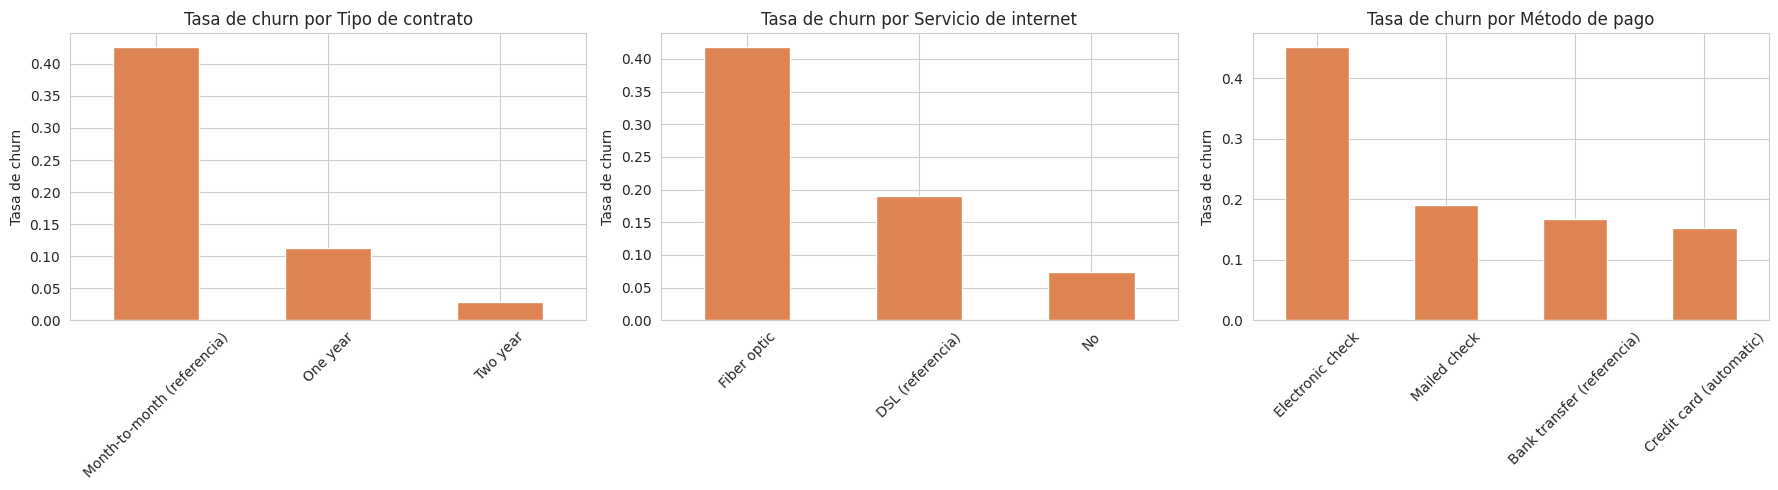

In [ ]:
# Calculamos la tasa de churn para cada grupo categórico de interés
contrato = tasa_churn_por_dummy(df, 'Contract_', 'Month-to-month (referencia)')
internet = tasa_churn_por_dummy(df, 'InternetService_', 'DSL (referencia)')
pago = tasa_churn_por_dummy(df, 'PaymentMethod_', 'Bank transfer (referencia)')

# Graficamos los tres grupos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (serie, titulo) in zip(axes, [(contrato, 'Tipo de contrato'),
                                        (internet, 'Servicio de internet'),
                                        (pago, 'Método de pago')]):
    serie.plot(kind='bar', color='#DD8452', ax=ax)  # Barras: tasa de churn por categoría
    ax.set_title(f'Tasa de churn por {titulo}')
    ax.set_ylabel('Tasa de churn')
    ax.tick_params(axis='x', rotation=45)             # Rota etiquetas largas para que no se encimen

plt.tight_layout()
plt.show()

#### 2.3.1 Interpretación de gráficos

El primer gráfico muestra que los clientes con contrato mes a mes tienen una tasa de churn considerablemente más alta (42%) que los de contrato de uno o dos años (11% y 3% respectivamente). Esto puede deberse a la falta de compromiso a largo plazo de este tipo de contrato, lo que facilita que el cliente decida cambiarse de proveedor con mayor facilidad.
En el segundo gráfico, los clientes con fibra óptica presentan la tasa de churn más alta (42%), muy por encima de los clientes con DSL (19%) y de quienes no tienen internet (7%). Esto podría representar una oportunidad de negocio: enfocar mejores promociones o retención en este segmento, además de evaluar posibles puntos de mejora en la calidad o el precio de los planes de fibra óptica.
Por último, el método de pago con cheque electrónico muestra la tasa de churn más alta (45%) frente a los demás métodos (mailed check 19%, bank transfer
17%, credit card 15%). Esto sugiere que valdría la pena evaluar ese proceso de pago específico, ya que podría estar generando fricción o insatisfacción en los clientes que lo usan.

### **2.4 Matriz de correlación**

Esta sección calcula la correlación de Pearson entre todas las variables (ya numéricas tras el encoding) y la variable objetivo Churn, para verificar de forma cuantitativa si el patrón observado en 2.3 (menor compromiso/automatización → mayor abandono) se sostiene frente al resto de las variables del dataset

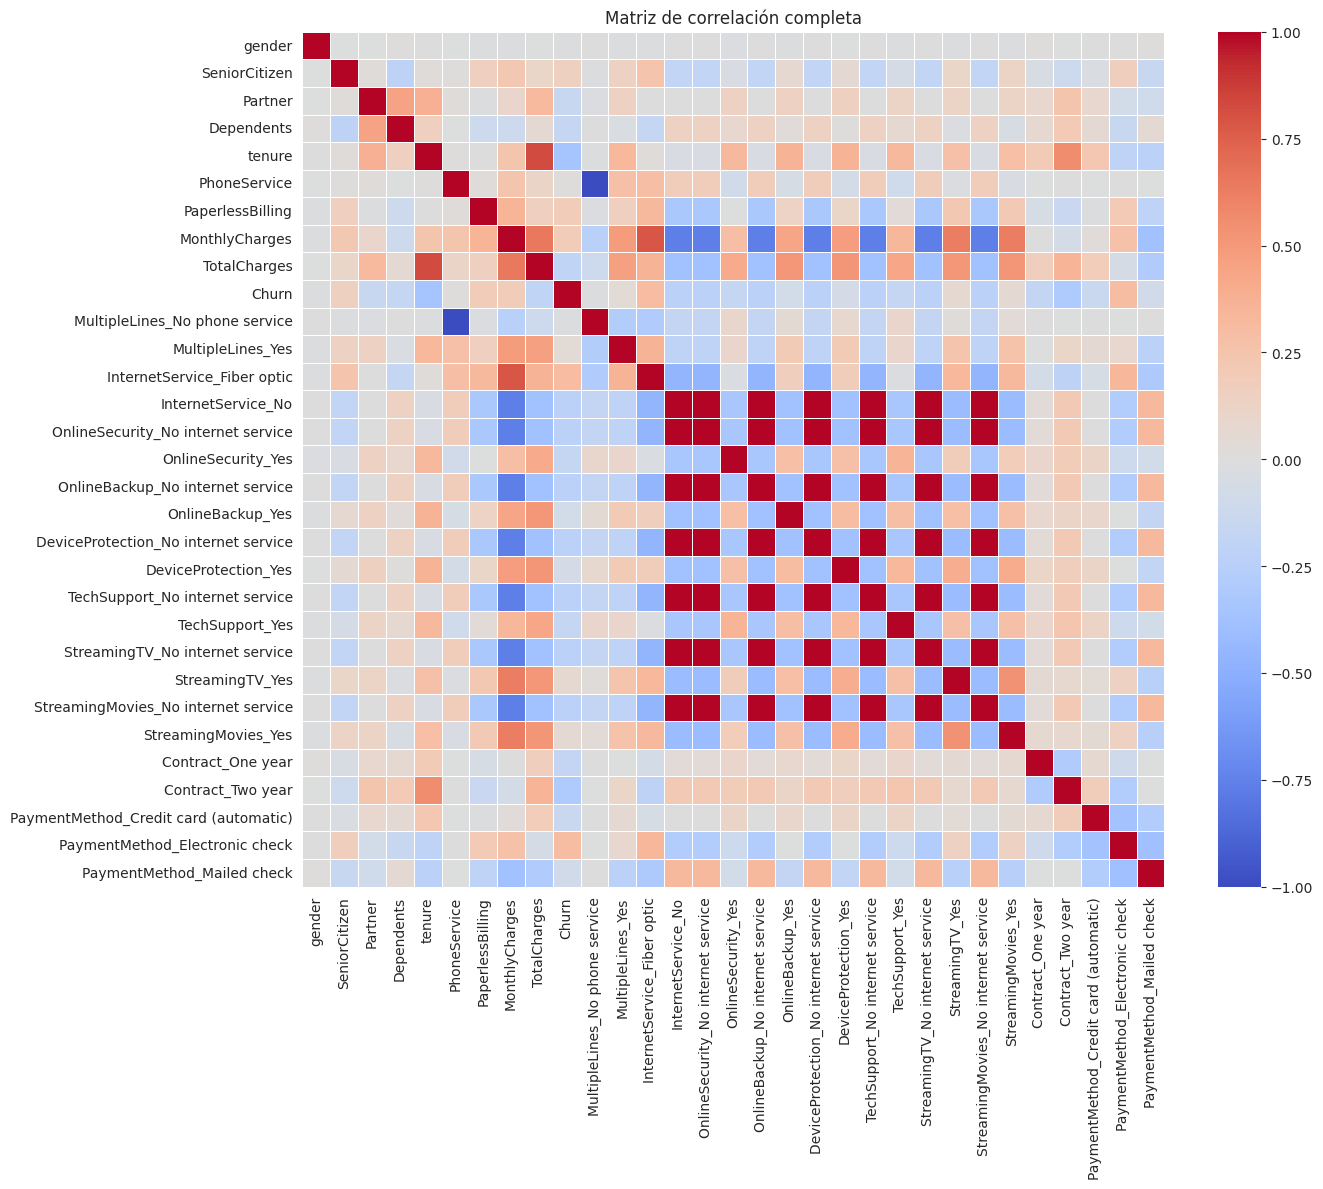

Mayor asociación con Churn (positiva):
SeniorCitizen                     0.150889
PaperlessBilling                  0.191825
MonthlyCharges                    0.193356
PaymentMethod_Electronic check    0.301919
InternetService_Fiber optic       0.308020
Name: Churn, dtype: float64

Mayor asociación con No Churn (negativa):
tenure                             -0.352229
Contract_Two year                  -0.302253
OnlineBackup_No internet service   -0.227890
InternetService_No                 -0.227890
TechSupport_No internet service    -0.227890
Name: Churn, dtype: float64


In [ ]:
# Matriz de correlación
matriz_corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    matriz_corr,
    cmap='coolwarm',      # Escala de color: azul (negativo) a rojo (positivo)
    center=0,             # El 0 (sin correlación) queda en el centro de la escala de color
    linewidths=0.5,
    ax=ax
)

ax.set_title('Matriz de correlación completa')
plt.tight_layout()
plt.show()

# Correlación específica de cada variable con Churn, ordenada
corr_churn = matriz_corr['Churn'].drop('Churn').sort_values()

print("Mayor asociación con Churn (positiva):")
print(corr_churn.tail(5))
print("\nMayor asociación con No Churn (negativa):")
print(corr_churn.head(5))

#### 2.4.1 Interpretación

La matriz de correlación confirma, de forma cuantitativa, buena parte del patrón observado en la sección 2.3. Las variables con mayor asociación positiva con Churn son InternetService_Fiber optic y PaymentMethod_Electronic check, seguidas de MonthlyCharges, PaperlessBilling y SeniorCitizen. Esto respalda lo visto anteriormente; la fibra óptica y el pago por cheque electrónico están entre los factores más asociados al abandono, aunque aquí se evidencia que ninguna variable individual tiene una correlación fuerte (todas están por debajo de 0.31), lo que sugiere que el churn depende de una combinación de factores más que de una sola causa dominante.

En cuanto a la asociación negativa o retención, tenure es la variable con mayor peso, seguida de Contract_Two year. Esto es consistente con el patrón observado, a mayor antigüedad y mayor compromiso contractual, menor probabilidad de abandono. Llama la atención que Contract_Month-to-month no aparece entre las 5 correlaciones más altas en ninguna dirección, lo que indica que, si bien mostró la tasa de churn más alta en el análisis categórico, su correlación lineal individual con Churn es más moderada que la de variables como tenure o el tipo de internet.

Un resultado adicional notable es que OnlineBackup_No internet service, InternetService_No y TechSupport_No internet service comparten exactamente la misma correlación (-0.228). Esto no es casualidad, son la misma población de clientes (quienes no tienen internet contratado), por lo que sus variables dummy están perfectamente correlacionadas entre sí, y en consecuencia comparten la misma relación con Churn.

### **2.5 Conclusión: Análisis Exploratorio**

El análisis exploratorio confirma que el churn no depende de una única variable dominante, sino de una combinación de factores relacionados con el tipo de servicio (fibra óptica), la modalidad de pago (cheque electrónico), el nivel de compromiso contractual (contratos cortos) y la antigüedad del cliente. Estas variables serán prioritarias a considerar en la etapa de modelado.

## **3. Entrenamiento y Evaluación del Modelo**

Con los datos ya limpios y las relaciones clave identificadas en el análisis exploratorio, esta sección se enfoca en construir un primer modelo de clasificación capaz de predecir el abandono de clientes. Se comienza con un modelo baseline (Regresión Logística), que servirá como punto de referencia para evaluar mejoras posteriores en la Sección 4. Dado el desbalance de clases detectado previamente (73.5% / 26.5%), la evaluación priorizará métricas como precisión, recall, F1-score y AUC-ROC por encima de la exactitud simple.

### **3.1 Separación Train/Test**

Antes de entrenar cualquier modelo, es necesario dividir el conjunto de datos en entrenamiento y prueba, garantizando que el modelo sea evaluado sobre datos que no ha visto durante su aprendizaje.


In [ ]:
from sklearn.model_selection import train_test_split

# Separamos features (X) de la variable objetivo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Dividimos en conjunto de entrenamiento (80%) y prueba (20%).
# stratify=y asegura que la proporción de churn (26.5%/73.5%) se mantenga
# igual en ambos conjuntos, evitando que el split empeore el desbalance ya existente.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (5634, 30)
Tamaño de prueba: (1409, 30)


#### 3.1.1 Justificación del split y manejo del desbalance

Se utilizó una proporción 80/20 para la división entre entrenamiento y prueba, un estándar ampliamente adoptado en proyectos de Machine Learning que ofrece un balance adecuado entre disponer de suficientes datos para el aprendizaje del modelo (5,634 registros) y mantener un conjunto de prueba con tamaño suficiente para una evaluación estadísticamente confiable (1,409 registros).

Para preservar la proporción original de clases (73.5% No Churn / 26.5% Churn) en ambos subconjuntos, se utilizó el parámetro `stratify=y` durante la división. Sin esto, existiría el riesgo de que, por azar, el conjunto de prueba quedara con una proporción de clases distinta a la real, lo cual distorsionaría la evaluación del modelo.

El desbalance de clases en sí no se corrige alterando la composición de los datos (por ejemplo, eliminando registros de la clase mayoritaria o duplicando registros de la minoritaria), sino mediante el parámetro `class_weight='balanced'` en el modelo. Esta técnica ajusta internamente el peso que cada clase tiene sobre la función de pérdida durante el entrenamiento, penalizando más los errores cometidos sobre la clase minoritaria (Churn). De esta forma, el modelo no tiene incentivo a simplemente predecir siempre "No Churn" para maximizar su exactitud aparente, sino que se ve forzado a aprender patrones genuinos que distingan a los clientes que sí abandonan.

### **3.2 Modelo Baseline — Regresión Logística**

Se entrena un modelo de Regresión Logística como punto de partida, por su simplicidad e interpretabilidad, lo cual permite establecer una referencia clara antes de probar modelos más complejos.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# La Regresión Logística es sensible a la escala de las variables numéricas
# (tenure, MonthlyCharges, TotalCharges tienen rangos muy distintos entre sí).
# Escalamos esas columnas para que ninguna domine el modelo solo por su magnitud.
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])
# Importante: fit_transform SOLO en train, transform (sin fit) en test,
# para no filtrar información del conjunto de prueba al entrenamiento (data leakage)

# class_weight='balanced' ajusta automáticamente el peso de cada clase
# de forma inversamente proporcional a su frecuencia, compensando el
# desbalance (73.5%/26.5%) detectado en el ETL.
modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

print("Modelo entrenado.")

Modelo entrenado.


### **3.3 Evaluación del Modelo Baseline**

Se evalúa el desempeño del modelo utilizando métricas apropiadas para el contexto de clases desbalanceadas, junto con una matriz de confusión y una curva ROC para visualizar su capacidad de discriminación.

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)

# Predicciones sobre el conjunto de prueba (nunca visto por el modelo)
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_proba_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]  # Probabilidad de churn (clase 1)

# classification_report da precision, recall y F1-score por clase,
# más apropiado que accuracy dado el desbalance de clases identificado en el ETL.
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



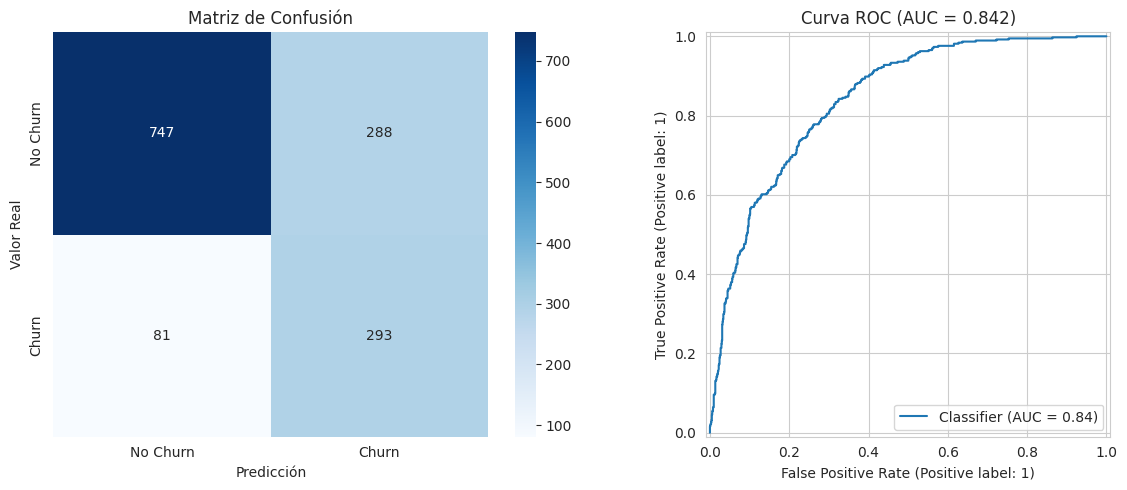

In [ ]:
# Matriz de confusión: muestra aciertos y errores por clase de forma visual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

# Curva ROC y AUC: mide qué tan bien el modelo distingue entre ambas clases
# en todos los posibles umbrales de decisión, no solo en el umbral de 0.5
RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=axes[1])
axes[1].set_title(f'Curva ROC (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')

plt.tight_layout()
plt.show()

#### 3.3.1 Interpretación de resultados

El modelo baseline alcanzó un AUC-ROC de 0.842, lo cual indica una buena capacidad de discriminación entre clientes que abandonan y los que no, consistente con los valores reportados en la literatura para este mismo dataset utilizando Regresión Logística.

Si bien la exactitud general (74%) es apenas superior a la que obtendría un modelo trivial que siempre prediga "No Churn" (~73.5%), esta métrica no es representativa del desempeño real del modelo en este contexto de clases desbalanceadas. El indicador más relevante desde una perspectiva de negocio es el recall de la clase Churn, el modelo logra identificar correctamente al 78% de los clientes que efectivamente abandonan el servicio, lo cual habilita estrategias proactivas de retención.

La precisión de la clase Churn (0.50) implica que aproximadamente la mitad de los clientes señalados como "en riesgo" no terminan abandonando (falsos positivos). Sin embargo, en el contexto específico de retención de clientes, el costo de un falso positivo (ofrecer una promoción innecesaria) es considerablemente menor al costo de un falso negativo (perder un cliente sin haber intervenido a tiempo), por lo que este trade-off resulta favorable desde una perspectiva estratégica.

Este modelo baseline sienta una referencia clara sobre la cual evaluar posibles mejoras en la Sección 4, ya sea mediante el ajuste de hiperparámetros o la comparación con algoritmos alternativos como Random Forest.

## **4. Mejora del Modelo**

Con el baseline establecido en la Sección 3, esta sección explora si un algoritmo distinto, Random Forest, mejora la capacidad de discriminación del modelo, y ajusta sus hiperparámetros principales mediante búsqueda en grilla (Grid Search) para optimizar su desempeño.

### **4.1 Modelo alternativo: Random Forest**

Se entrena un Random Forest como alternativa a la Regresión Logística, dado que este algoritmo puede capturar relaciones no lineales e interacciones entre variables sin necesidad de escalado previo.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest no requiere escalado de variables (a diferencia de Regresión
# Logística), ya que se basa en divisiones por umbral, no en distancias.
# Usamos los datos sin escalar (X_train, X_test originales).
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # Mismo manejo de desbalance que en el baseline
    random_state=42
)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_rf):.3f}")

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

AUC-ROC: 0.829


#### 4.1.1 Interpretación

El Random Forest (configuración por defecto) presenta un desempeño mixto frente al baseline de Regresión Logística. Si bien mejora la precisión de la clase Churn (de 0.50 a 0.63) y la exactitud general (de 0.74 a 0.79), su AUC-ROC desciende levemente (de 0.842 a 0.829) y, más importante aún, su recall de Churn cae de forma considerable (de 0.78 a 0.49).

Dado que el objetivo de negocio prioriza identificar la mayor cantidad posible de clientes en riesgo real de abandono, y que el costo de un falso negativo (no detectar a un cliente que se va) es mayor al de un falso positivo (ofrecer una promoción a quien no se iba a ir), este resultado indica que el Random Forest por defecto es, en su forma actual, menos adecuado para el objetivo del proyecto que el baseline, a pesar de mostrar mejores métricas superficiales como accuracy y precisión. Esto refuerza la importancia de elegir modelos en función de la métrica alineada al problema de negocio, y no de la exactitud general por sí sola. Se explora a continuación si el ajuste de hiperparámetros permite recuperar el recall sin sacrificar la ganancia obtenida en precisión.

### **4.2 Ajuste de hiperparámetros (Grid Search)**

Se realiza una búsqueda acotada sobre los hiperparámetros más influyentes del Random Forest, utilizando validación cruzada para evitar sobreajuste en la selección.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Grilla acotada (pocos valores) para mantener el tiempo de cómputo razonable,
# priorizando los hiperparámetros con mayor impacto conocido en Random Forest.
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='roc_auc',  # Optimizamos directamente para AUC, la métrica clave del proyecto
    cv=5,               # Validación cruzada de 5 particiones
    n_jobs=-1           # Usa todos los núcleos disponibles para acelerar el cómputo
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluamos el mejor modelo encontrado sobre el conjunto de prueba
mejor_rf = grid_search.best_estimator_
y_pred_best = mejor_rf.predict(X_test)
y_proba_best = mejor_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_best):.3f}")

Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.55      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

AUC-ROC: 0.844


#### 4.2.1 Interpretación

El ajuste de hiperparámetros mediante Grid Search identificó como configuración óptima `max_depth=10`, `min_samples_leaf=5` y `n_estimators=200`. Este modelo logra el mejor equilibrio entre las tres versiones evaluadas: recupera el recall de Churn al mismo nivel que el baseline (0.78), evitando la pérdida de sensibilidad observada en el Random Forest por defecto, mientras mejora la precisión (0.55 vs. 0.50) y el F1-score (0.64 vs. 0.61) respecto a la Regresión Logística. Adicionalmente, alcanza el AUC-ROC más alto de los tres modelos (0.844).

El parámetro `min_samples_leaf=5` resulta particularmente relevante, al exigir un mínimo de observaciones por hoja, se limita la tendencia del árbol a sobreajustarse a patrones específicos del conjunto de entrenamiento, permitiendo una mejor generalización sobre la clase minoritaria.

### **4.3 Comparación de modelos**

Se comparan las tres versiones del modelo entrenadas hasta el momento, utilizando AUC-ROC como métrica principal de comparación.

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Logística (baseline)', 'Random Forest (default)', 'Random Forest (tuned)'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_best)
    ]
})

print(comparacion)

                           Modelo   AUC-ROC
0  Regresión Logística (baseline)  0.841732
1         Random Forest (default)  0.829288
2           Random Forest (tuned)  0.844110


#### 4.3.1 Interpretación de tabla comparativa

La tabla comparativa confirma que el Random Forest ajustado (tuned) obtuvo el AUC-ROC más alto de los tres modelos evaluados (0.844), superando tanto al Random Forest por defecto (0.829) como al baseline de Regresión Logística (0.842), aunque por un margen reducido. Es importante señalar que, si bien la distribución de clases del dataset (73.5% No Churn / 26.5% Churn) representa una limitación inherente que dificulta alcanzar métricas más altas de forma generalizada, el modelo ajustado logró un desempeño sólido dentro de ese contexto, encontrando el mejor equilibrio entre las métricas relevantes para el objetivo de negocio planteado.

### **4.4 Conclusión: Mejora del Modelo**

Tras comparar tres configuraciones de modelos, el Random Forest con hiperparámetros ajustados (`max_depth=10`, `min_samples_leaf=5`, `n_estimators=200`) resulta el modelo final seleccionado para este proyecto. Este modelo preserva la capacidad de detección de clientes en riesgo de abandono (recall de 0.78, igual al baseline) mientras mejora la precisión, el F1-score y el AUC-ROC frente a la Regresión Logística inicial, logrando el mejor balance general entre las métricas relevantes para el objetivo de negocio planteado. Este será el modelo utilizado en las siguientes etapas de serialización y despliegue.

## **5. Serialización del Modelo**

Una vez seleccionado el modelo final (Random Forest ajustado), se procede a exportarlo a un archivo persistente. Esto permite que el modelo entrenado sea reutilizado posteriormente por la API sin necesidad de re-ejecutar el proceso de entrenamiento, separando así la fase de experimentación de la fase de producción.

In [ ]:
import joblib  # Librería estándar para serializar objetos de Python, especialmente modelos de scikit-learn

# Guardamos el modelo final (el Random Forest ajustado del Grid Search) en un archivo .pkl
# Este archivo contiene toda la lógica entrenada del modelo: los árboles, los splits, todo.
model_path = '/content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/churn_model.pkl'
joblib.dump(mejor_rf, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: /content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/churn_model.pkl


También guardamos la lista de columnas que el modelo espera como input, en el mismo orden en que fueron usadas durante el entrenamiento. Esto es crucial, cuando la API reciba datos nuevos de un cliente, tiene que construir el mismo conjunto de columnas exactamente en el mismo orden, o el modelo va a fallar o dar predicciones incorrectas.

In [ ]:
columns_path = '/content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/model_columns.pkl'
joblib.dump(X_train.columns.tolist(), columns_path)

print(f"Columnas del modelo guardadas en: {columns_path}")

Columnas del modelo guardadas en: /content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/model_columns.pkl


In [ ]:
# También guardamos el scaler entrenado en la Sección 3, aunque el modelo final
# sea Random Forest (que no lo necesita), por si en el futuro se quiere comparar
# de nuevo con la Regresión Logística o hacer ensamble de modelos.
scaler_path = '/content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/scaler.pkl'
joblib.dump(scaler, scaler_path)

print(f"Scaler guardado en: {scaler_path}")

Scaler guardado en: /content/drive/MyDrive/Colab Notebooks/datasets/telco-churn/scaler.pkl


## **6. API REST con FastAPI**
Con el modelo final serializado, se desarrolló una API REST utilizando FastAPI para exponerlo como un servicio capaz de recibir datos de un cliente y devolver una predicción en tiempo real. La API replica internamente el mismo proceso de encoding aplicado durante el ETL, garantizando consistencia entre los datos usados en entrenamiento y los datos recibidos en producción.

Se implementó además un frontend simple (HTML, CSS y JavaScript) que consume esta API, permitiendo ingresar el perfil de un cliente a través de un formulario y visualizar tanto la probabilidad de abandono como recomendaciones de retención generadas dinámicamente en base a los factores de riesgo detectados en el análisis exploratorio.

El código completo de la API se encuentra en [`api/main.py`](../api/main.py), y el frontend en [`frontend/`](../frontend/).

### **6.1 Endpoints disponibles**

- `GET /` — Sirve el frontend (formulario de predicción)
- `POST /predict` — Recibe los datos crudos de un cliente (antes del encoding) y devuelve la predicción de churn junto con la probabilidad asociada

#### **6.1.1 Interpretación**

La decisión de encapsular el encoding dentro de la API (en lugar de exigir que quien la consuma envíe los datos ya codificados) responde a una consideración de diseño relevante: en un escenario real, un sistema externo (por ejemplo, un CRM) enviaría datos crudos y legibles de un cliente, no columnas dummy. Replicar el preprocesamiento dentro de la API mantiene la interfaz del servicio simple y desacoplada de los detalles internos del modelo.

## **7. Containerización con Docker**
Empaquetado de la API para garantizar reproducibilidad del entorno.

## **8. Despliegue**
Publicación del servicio en una plataforma cloud accesible públicamente.

## **9. Dashboard Interactivo**
Interfaz en Streamlit para consumir la API sin conocimientos técnicos.